# Step 5: Challenger Model — LightGBM

Trains a LightGBM regressor on the engineered features from Step 3 and compares against the Step 4 baseline.

Key design choices:
- **Target**: `log1p(sales)` — normalises the skewed sales distribution; RMSE on log target ≡ RMSLE on original target
- **Validation**: same time-based split as Step 4 (last 28 days of training)
- **Early stopping**: prevents overfitting, automatically finds the optimal number of trees
- **NaN handling**: LightGBM natively handles NaN lag features

In [14]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import joblib
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DATA_DIR   = 'data/'
MODEL_DIR  = 'models/'

import os
os.makedirs(MODEL_DIR, exist_ok=True)

VAL_START = pd.Timestamp('2017-07-19')
VAL_END   = pd.Timestamp('2017-08-15')
TR_END    = pd.Timestamp('2017-07-18')

BASELINE_RMSLE = 0.6900   # from Step 4

## 1. Load Feature Data

In [15]:
train_feat = pd.read_parquet(DATA_DIR + 'features_train.parquet')
test_feat  = pd.read_parquet(DATA_DIR + 'features_test.parquet')

print(f'train_feat: {train_feat.shape}')
print(f'test_feat:  {test_feat.shape}')

train_feat: (3000888, 39)
test_feat:  (28512, 38)


## 2. Define Feature Columns

In [16]:
# Columns that are NOT features (metadata / target)
NON_FEATURES = {'id', 'date', 'sales'}

FEATURES = [c for c in train_feat.columns if c not in NON_FEATURES]

print(f'Number of features: {len(FEATURES)}')
print('Features:', FEATURES)

Number of features: 36
Features: ['store_nbr', 'onpromotion', 'cluster', 'oil_price', 'transactions', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'is_holiday', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'is_weekend', 'is_month_start', 'is_month_end', 'is_on_promo', 'log_onpromotion', 'oil_ma7', 'oil_ma28', 'lag_7', 'lag_14', 'lag_28', 'lag_35', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_max_28', 'family_enc', 'store_type_enc', 'city_enc', 'state_enc']


## 3. Train / Validation Split

In [17]:
tr  = train_feat[train_feat['date'] <= TR_END]
val = train_feat[(train_feat['date'] >= VAL_START) & (train_feat['date'] <= VAL_END)]

X_tr  = tr[FEATURES]
y_tr  = np.log1p(tr['sales'])        # train on log scale

X_val = val[FEATURES]
y_val = np.log1p(val['sales'])

print(f'X_tr  shape: {X_tr.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'\nTrain: {tr["date"].min().date()} -> {tr["date"].max().date()}')
print(f'Val:   {val["date"].min().date()} -> {val["date"].max().date()}')

X_tr  shape: (2950992, 36)
X_val shape: (49896, 36)

Train: 2013-01-01 -> 2017-07-18
Val:   2017-07-19 -> 2017-08-15


## 4. Train LightGBM

Training on 3M rows typically takes **5–10 minutes** on a laptop CPU.  
Early stopping halts training when validation RMSE stops improving.

In [18]:
params = {
    'objective':        'regression',
    'metric':           'rmse',        # RMSE on log target = RMSLE on original
    'n_estimators':     2000,
    'learning_rate':    0.05,
    'num_leaves':       63,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':     5,
    'lambda_l1':        0.1,
    'lambda_l2':        0.1,
    'verbose':          -1,
    'random_state':     42,
    'n_jobs':           -1,
}

model = lgb.LGBMRegressor(**params)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=100),
    ]
)

print(f'\nBest iteration: {model.best_iteration_}')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.394095
[200]	valid_0's rmse: 0.388236
[300]	valid_0's rmse: 0.384647
[400]	valid_0's rmse: 0.382692
[500]	valid_0's rmse: 0.381457
[600]	valid_0's rmse: 0.37993
[700]	valid_0's rmse: 0.378825
[800]	valid_0's rmse: 0.378148
[900]	valid_0's rmse: 0.377594
[1000]	valid_0's rmse: 0.377007
[1100]	valid_0's rmse: 0.376487
[1200]	valid_0's rmse: 0.376093
[1300]	valid_0's rmse: 0.375738
[1400]	valid_0's rmse: 0.375408
[1500]	valid_0's rmse: 0.375149
[1600]	valid_0's rmse: 0.374962
[1700]	valid_0's rmse: 0.374759
[1800]	valid_0's rmse: 0.374551
[1900]	valid_0's rmse: 0.37434
[2000]	valid_0's rmse: 0.374165
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.374165

Best iteration: 2000


## 5. Evaluate on Validation Set

In [19]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

val_log_pred  = model.predict(X_val)
val_pred      = np.expm1(val_log_pred).clip(0)   # back to original scale
val_true      = val['sales'].values

score_lgb = rmsle(val_true, val_pred)
improvement  = (BASELINE_RMSLE - score_lgb) / BASELINE_RMSLE * 100

print('========== Validation Results ==========')
print(f'Baseline RMSLE  : {BASELINE_RMSLE:.4f}')
print(f'LightGBM RMSLE  : {score_lgb:.4f}')
print(f'Improvement     : {improvement:.1f}%')
print('========================================')

========== Validation Results ==========
Baseline RMSLE  : 0.6900
LightGBM RMSLE  : 0.3742
Improvement     : 45.8%


## 6. Feature Importance

Top 15 features:
        feature  importance
     family_enc       10480
   transactions        8767
  rolling_std_7        8694
    day_of_year        8207
 rolling_mean_7        7966
rolling_mean_28        6587
   day_of_month        6252
          lag_7        5700
         lag_35        5369
      oil_price        5203
rolling_mean_14        5132
    day_of_week        4964
         lag_14        4758
         lag_28        4691
       oil_ma28        4417


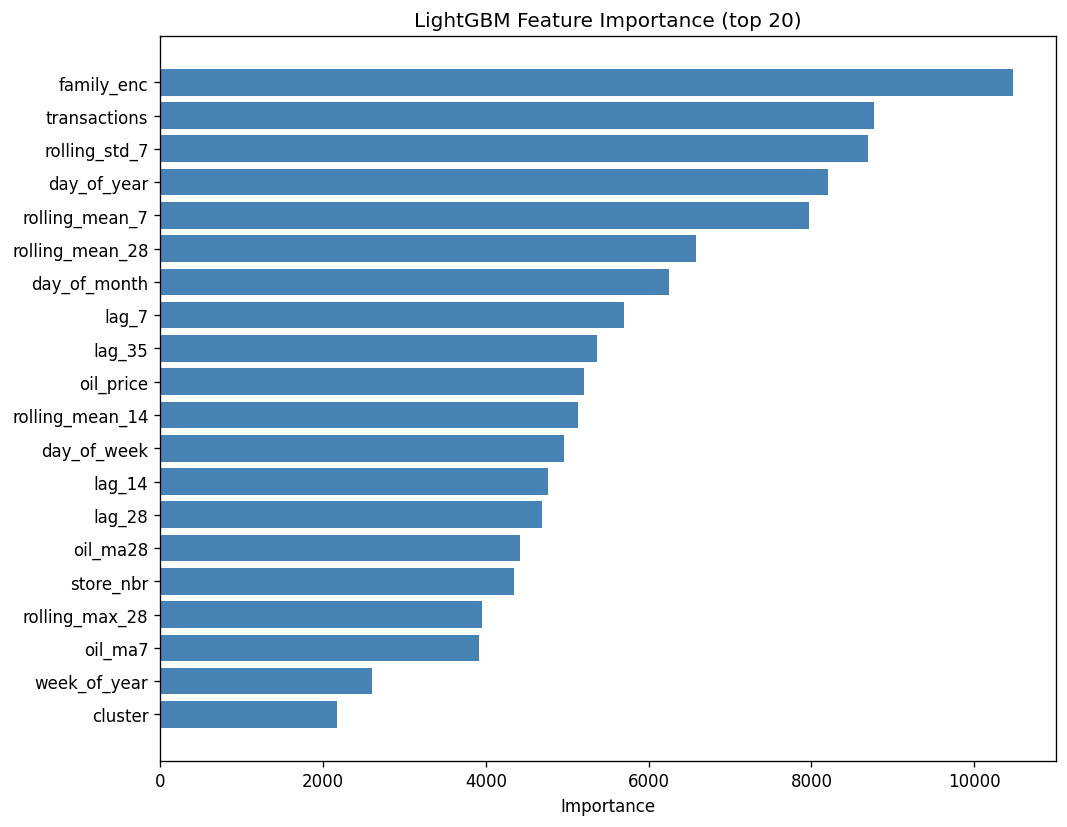

In [20]:
importance = pd.DataFrame({
    'feature':    FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print('Top 15 features:')
print(importance.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top20 = importance.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue', edgecolor='none')
ax.set_title('LightGBM Feature Importance (top 20)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Baseline vs LightGBM Comparison

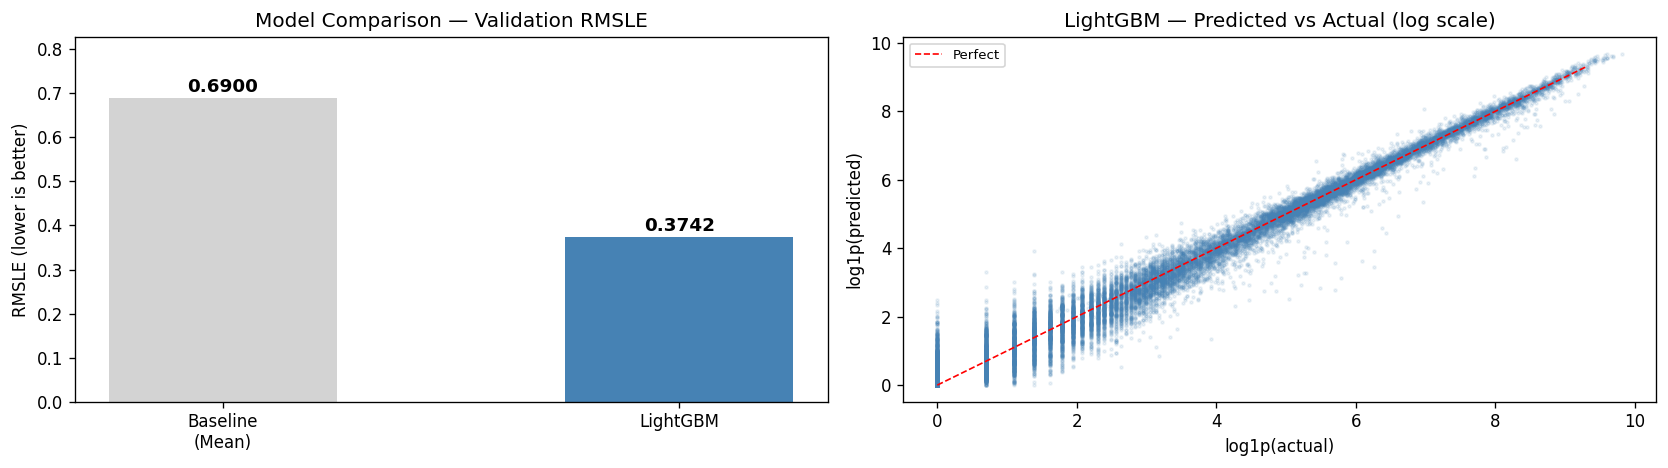

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart comparison
models    = ['Baseline\n(Mean)', 'LightGBM']
scores    = [BASELINE_RMSLE, score_lgb]
colors    = ['lightgray', 'steelblue']
bars = axes[0].bar(models, scores, color=colors, edgecolor='none', width=0.5)
for bar, s in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, s + 0.005, f'{s:.4f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(scores) * 1.2)
axes[0].set_ylabel('RMSLE (lower is better)')
axes[0].set_title('Model Comparison — Validation RMSLE')

# Predicted vs actual scatter (sample)
idx = np.random.choice(len(val_true), size=min(20000, len(val_true)), replace=False)
axes[1].scatter(np.log1p(val_true[idx]), np.log1p(val_pred[idx]),
                alpha=0.1, s=3, color='steelblue')
max_v = np.log1p(val_true).max() * 0.95
axes[1].plot([0, max_v], [0, max_v], 'r--', linewidth=1, label='Perfect')
axes[1].set_title('LightGBM — Predicted vs Actual (log scale)')
axes[1].set_xlabel('log1p(actual)')
axes[1].set_ylabel('log1p(predicted)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Error Analysis

In [22]:
val_result = val[['date', 'store_nbr', 'family_enc', 'sales']].copy()
val_result['pred'] = val_pred
val_result['sq_log_err'] = (np.log1p(val_result['pred']) - np.log1p(val_result['sales'])) ** 2

# RMSLE by family
family_rmsle = val_result.groupby('family_enc')['sq_log_err'].mean().apply(np.sqrt).sort_values(ascending=False)
print('RMSLE by family_enc (top 10 worst):')
print(family_rmsle.head(10).round(4))

# RMSLE by store
store_rmsle = val_result.groupby('store_nbr')['sq_log_err'].mean().apply(np.sqrt).sort_values(ascending=False)
print('\nRMSLE by store (top 10 worst):')
print(store_rmsle.head(10).round(4))

RMSLE by family_enc (top 10 worst):
family_enc
21    0.6112
13    0.5429
6     0.5371
14    0.5286
31    0.5126
23    0.5043
0     0.4940
32    0.4733
19    0.4675
2     0.4671
Name: sq_log_err, dtype: float64

RMSLE by store (top 10 worst):
store_nbr
19    0.4670
22    0.4469
26    0.4406
14    0.4312
36    0.4295
30    0.4273
34    0.4175
43    0.4174
28    0.4164
32    0.4144
Name: sq_log_err, dtype: float64


## 9. Retrain on Full Data & Predict Test Set

In [23]:
# Use best_iteration_ found during early stopping — no need to retrain from scratch
# Instead, retrain with n_estimators = best_iteration_ on full training data
best_n = model.best_iteration_
print(f'Retraining on full data with n_estimators={best_n} ...')

final_params = {**params, 'n_estimators': best_n}
final_model = lgb.LGBMRegressor(**final_params)
final_model.fit(
    train_feat[FEATURES],
    np.log1p(train_feat['sales']),
    callbacks=[lgb.log_evaluation(period=200)]
)

print('Done.')

Retraining on full data with n_estimators=2000 ...
Done.


In [24]:
# Fix: fill NaN lag features in test set before predicting
# NaN lag_7/rolling_mean_7 appear for Aug 23-31 (56% of test rows).
# The model associates NaN lags with early 2013 data (low sales), causing underprediction.
# Substitute with the nearest available lag as a proxy.
test_fixed = test_feat[FEATURES].copy()

# lag_7 NaN -> lag_14 (if available), else lag_28
test_fixed['lag_7']  = test_fixed['lag_7'].fillna(test_fixed['lag_14']).fillna(test_fixed['lag_28'])
test_fixed['lag_14'] = test_fixed['lag_14'].fillna(test_fixed['lag_28'])

# rolling_mean_7 NaN -> rolling_mean_14, else rolling_mean_28
test_fixed['rolling_mean_7']  = test_fixed['rolling_mean_7'].fillna(test_fixed['rolling_mean_14']).fillna(test_fixed['rolling_mean_28'])
test_fixed['rolling_mean_14'] = test_fixed['rolling_mean_14'].fillna(test_fixed['rolling_mean_28'])

# rolling_std_7 NaN -> fill with 0 (no variance info = assume stable)
test_fixed['rolling_std_7'] = test_fixed['rolling_std_7'].fillna(0)

print(f'NaN in test after fix:')
print(test_fixed.isnull().sum()[test_fixed.isnull().sum() > 0])

# Generate test predictions
test_log_pred = final_model.predict(test_fixed)
test_pred     = np.expm1(test_log_pred).clip(0)

# Fix ID order: sort submission to match original test.csv order
submission = (
    pd.DataFrame({'id': test_feat['id'].values, 'sales': test_pred})
    .sort_values('id')
    .reset_index(drop=True)
)

submission.to_csv(DATA_DIR + 'submission_lgb.csv', index=False)

print(f'\nSaved data/submission_lgb.csv  ({len(submission):,} rows)')
print(f'Pred stats after fix:')
print(submission['sales'].describe().round(2))

NaN in test after fix:
Series([], dtype: int64)

Saved data/submission_lgb.csv  (28,512 rows)
Pred stats after fix:
count    28512.00
mean        15.84
std         58.25
min          0.00
25%          0.83
50%          2.81
75%          9.78
max        943.11
Name: sales, dtype: float64


## 10. Save Model

In [25]:
joblib.dump(final_model, MODEL_DIR + 'lgb_model.pkl')
print(f'Model saved to {MODEL_DIR}lgb_model.pkl')

# Verify it loads correctly
loaded = joblib.load(MODEL_DIR + 'lgb_model.pkl')
check  = np.expm1(loaded.predict(test_feat[FEATURES][:5])).clip(0)
print(f'Load verification passed — sample predictions: {check.round(2)}')

Model saved to models/lgb_model.pkl
Load verification passed — sample predictions: [0.84 0.95 0.36 0.75 0.87]


## 11. Final Summary

In [26]:
print('============ Final Summary ============')
print(f'Validation period  : {VAL_START.date()} -> {VAL_END.date()}')
print(f'Metric             : RMSLE')
print()
print(f'  Baseline (Mean)  : {BASELINE_RMSLE:.4f}')
print(f'  LightGBM         : {score_lgb:.4f}  ({improvement:.1f}% improvement)')
print()
print(f'Best n_estimators  : {best_n}')
print(f'Number of features : {len(FEATURES)}')
print()
print(f'Outputs:')
print(f'  models/lgb_model.pkl          (deploy to cloud)')
print(f'  data/submission_lgb.csv       (test predictions)')
print('=======================================')

============ Final Summary ============
Validation period  : 2017-07-19 -> 2017-08-15
Metric             : RMSLE

  Baseline (Mean)  : 0.6900
  LightGBM         : 0.3742  (45.8% improvement)

Best n_estimators  : 2000
Number of features : 36

Outputs:
  models/lgb_model.pkl          (deploy to cloud)
  data/submission_lgb.csv       (test predictions)
